In [1]:
%pylab inline
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import seaborn as sns
import scvi
import matplotlib.pyplot as plt

rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

import warnings
warnings.filterwarnings("ignore")

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/liu/anaconda3/envs/bioSoft/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


# Loading data...

In [2]:
# Load Tasic data
ad_tasic = sc.read('../Meis2AnnotedbyTasicData/TasicData/Tasic_mice_filtered.h5')

In [3]:
ad_tasic

AnnData object with n_obs × n_vars = 23178 × 39281
    obs: 'title', 'source_name', 'organism', 'donor_id', 'donor_sex', 'donor_genotype', 'injection_type', 'injection_target', 'injected_material', 'dissected_region', 'dissected_layer', 'facs_gating', 'facs_date', 'rna_amplification_set', 'sequencing_tube', 'sequencing_batch', 'sequencing_qc_pass_fail', 'cell_class', 'cell_subclass', 'cell_cluster', 'molecule', 'SRA_Run', 'GEO_Sample', 'GEO_Sample_Title', 'n_counts'
    var: 'n_cells'
    layers: 'counts'

In [4]:
np.unique(ad_tasic.obs['cell_subclass'])

array(['Astro', 'Batch Grouping', 'CR', 'Doublet', 'Endo',
       'High Intronic', 'L2/3 IT', 'L4', 'L5 IT', 'L5 PT', 'L6 CT',
       'L6 IT', 'L6b', 'Lamp5', 'Low Quality', 'Macrophage', 'Meis2',
       'NP', 'No Class', 'Oligo', 'Peri', 'Pvalb', 'SMC', 'Serpinf1',
       'Sncg', 'Sst', 'VLMC', 'Vip', 'nan'], dtype=object)

In [5]:
ad_tasic = ad_tasic[ad_tasic.obs['cell_class'].isin(['Non-Neuronal'])]
ad_tasic

View of AnnData object with n_obs × n_vars = 1006 × 39281
    obs: 'title', 'source_name', 'organism', 'donor_id', 'donor_sex', 'donor_genotype', 'injection_type', 'injection_target', 'injected_material', 'dissected_region', 'dissected_layer', 'facs_gating', 'facs_date', 'rna_amplification_set', 'sequencing_tube', 'sequencing_batch', 'sequencing_qc_pass_fail', 'cell_class', 'cell_subclass', 'cell_cluster', 'molecule', 'SRA_Run', 'GEO_Sample', 'GEO_Sample_Title', 'n_counts'
    var: 'n_cells'
    layers: 'counts'

In [6]:
sc.tl.pca(ad_tasic, svd_solver='arpack')
sc.pp.neighbors(ad_tasic, n_neighbors=10, n_pcs=40)
sc.tl.umap(ad_tasic,random_state=44)

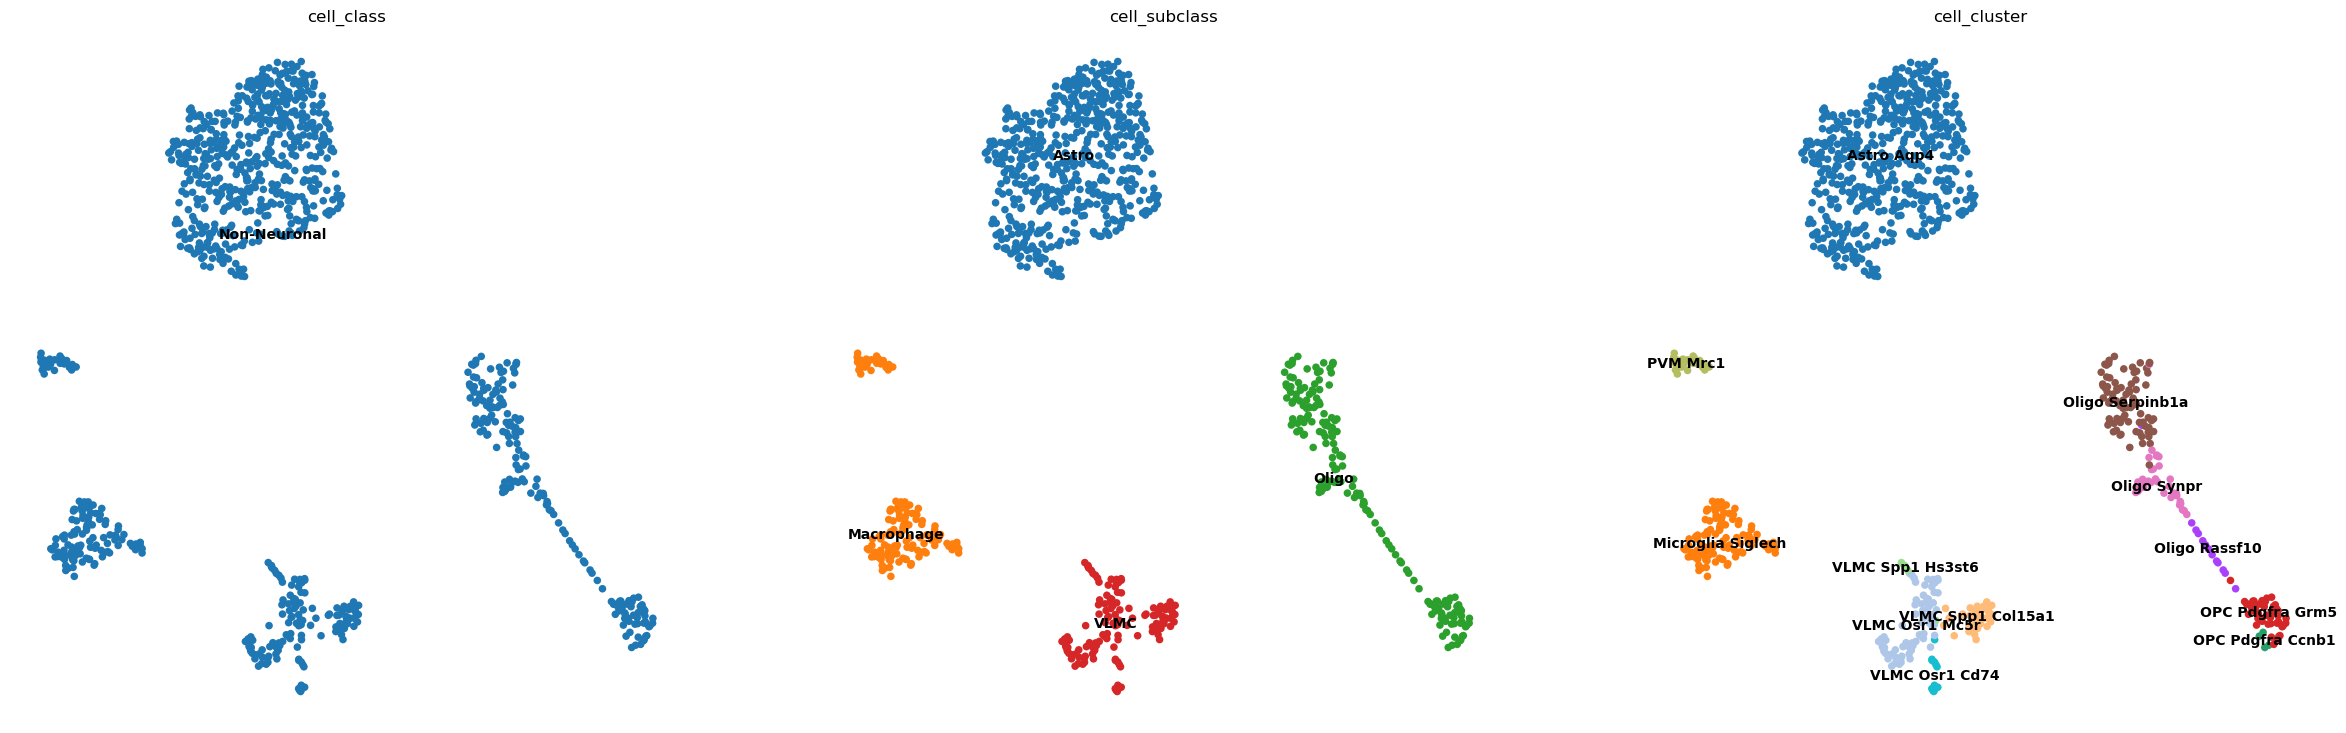

In [7]:
figsize(9,9)
sc.pl.umap(ad_tasic,color=['cell_class','cell_subclass','cell_cluster'],frameon=False,legend_loc='on data')

In [8]:
ad_tasic = ad_tasic[ad_tasic.obs['cell_subclass'].isin(['Astro','Macrophage','Oligo']),]
ad_tasic

View of AnnData object with n_obs × n_vars = 873 × 39281
    obs: 'title', 'source_name', 'organism', 'donor_id', 'donor_sex', 'donor_genotype', 'injection_type', 'injection_target', 'injected_material', 'dissected_region', 'dissected_layer', 'facs_gating', 'facs_date', 'rna_amplification_set', 'sequencing_tube', 'sequencing_batch', 'sequencing_qc_pass_fail', 'cell_class', 'cell_subclass', 'cell_cluster', 'molecule', 'SRA_Run', 'GEO_Sample', 'GEO_Sample_Title', 'n_counts'
    var: 'n_cells'
    uns: 'pca', 'neighbors', 'umap', 'cell_class_colors', 'cell_subclass_colors', 'cell_cluster_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [9]:
cell_subclass = ad_tasic.obs['cell_subclass'].astype('str')
cell_subclass[ad_tasic.obs['cell_cluster'].isin(['OPC Pdgfra Grm5','OPC Pdgfra Ccnb1'])] = 'OPC'

ad_tasic.obs['cell_subclass']=cell_subclass.astype('category')

In [10]:
ad_tasic.obs['cell_subclass']

F2S4_151217_010_C01    Oligo
F2S4_151217_014_E01    Oligo
F2S4_151217_012_F01    Oligo
F2S4_151223_013_F01    Oligo
F2S4_160115_024_C01    Astro
                       ...  
F2S4_171204_005_H01    Oligo
F2S4_171121_009_C01    Astro
F2S4_171121_009_E01    Astro
F2S4_171129_010_B01    Astro
F2S4_171204_006_A01    Astro
Name: cell_subclass, Length: 873, dtype: category
Categories (4, object): ['Astro', 'Macrophage', 'OPC', 'Oligo']

In [11]:
# ===========mapping mouse gene names to monkey gene names ====================

# load data from file. 
gene_mus2mk = pd.read_csv('../refGenesXspecies/mouse2monkey.csv',sep='\t')
# remove the nans in mouse gene names and mobkey gene names.
gene_mus2mk = gene_mus2mk[~gene_mus2mk['Crab-eating macaque gene name'].isna() & ~gene_mus2mk['Gene name'].isna()]
# remove the duplicates in monkey gene names
gene_mus2mk = gene_mus2mk.loc[gene_mus2mk['Crab-eating macaque gene name'].drop_duplicates(keep='first').index,]

# crate a gene name dict of gene names between mouse and monkey.
gene_dict = dict(zip(gene_mus2mk['Gene name'],gene_mus2mk['Crab-eating macaque gene name']))

# mapping mouse gene names to monkey gene names
ad_index = ad_tasic.var_names
new_index = ad_index.map(lambda x: gene_dict.get(x, 'NA'))

ad_tasic.var_names = new_index

In [12]:
ad_tasic = ad_tasic[:,ad_tasic.var_names !='NA']

In [13]:
ad_tasic

View of AnnData object with n_obs × n_vars = 873 × 14549
    obs: 'title', 'source_name', 'organism', 'donor_id', 'donor_sex', 'donor_genotype', 'injection_type', 'injection_target', 'injected_material', 'dissected_region', 'dissected_layer', 'facs_gating', 'facs_date', 'rna_amplification_set', 'sequencing_tube', 'sequencing_batch', 'sequencing_qc_pass_fail', 'cell_class', 'cell_subclass', 'cell_cluster', 'molecule', 'SRA_Run', 'GEO_Sample', 'GEO_Sample_Title', 'n_counts'
    var: 'n_cells'
    uns: 'pca', 'neighbors', 'umap', 'cell_class_colors', 'cell_cluster_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [14]:
ad_ins = sc.read('../data_h5/Insular_sorted_clusters.h5ad')
ad_ins

AnnData object with n_obs × n_vars = 122663 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', '

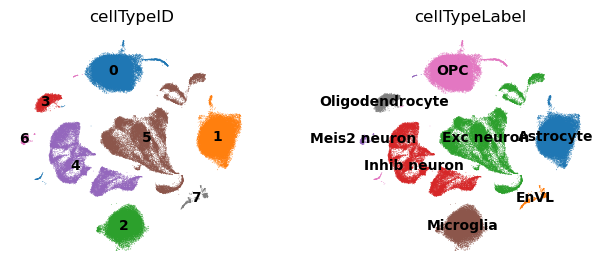

In [15]:
figsize(3,3)
sc.pl.umap(ad_ins,color=['cellTypeID','cellTypeLabel'],frameon=False,legend_loc='on data')

In [16]:
ad_glia = ad_ins[ad_ins.obs['cellTypeID'].isin(['0','1','2','3'])]

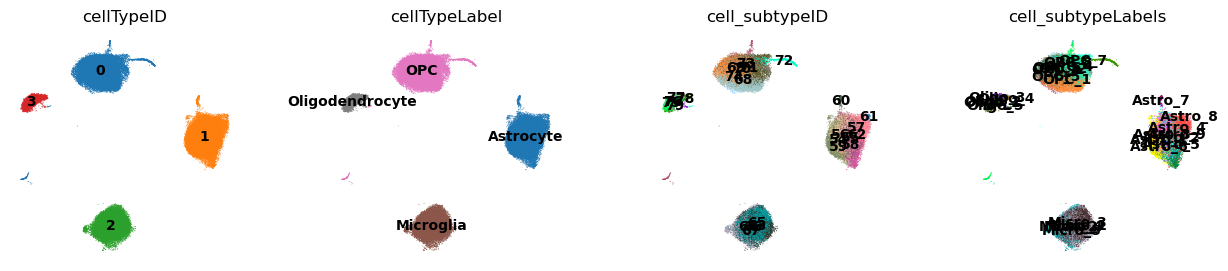

In [17]:
figsize(3,3)
sc.pl.umap(ad_glia,color=['cellTypeID','cellTypeLabel','cell_subtypeID','cell_subtypeLabels'],frameon=False,legend_loc='on data')

In [18]:
ad_glia

View of AnnData object with n_obs × n_vars = 83283 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharm

In [19]:
sc.pp.subsample(ad_glia,0.03)

In [20]:
ad_glia

AnnData object with n_obs × n_vars = 2498 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', 'X_

### build new scanpy AnnData objects and combine...

In [21]:
ad_mus = sc.AnnData( ad_tasic.layers['counts'], dict(obs_names=ad_tasic.obs_names),dict(var_names=ad_tasic.var_names) )
ad_mus.obs['species'] = 'mus'
ad_mus.obs['sequencing_batch_mus'] = ad_tasic.obs['sequencing_batch']
ad_mus.obs['cell_class'] = ad_tasic.obs['cell_class']
ad_mus.obs['cell_subclass'] = ad_tasic.obs['cell_subclass']

In [22]:
ad_mk = sc.AnnData( ad_glia.layers['counts'], dict(obs_names=ad_glia.obs_names),dict(var_names=ad_glia.var_names) )
ad_mk.obs['species'] = 'mk'
ad_mk.obs['sequenceing_batch_mk'] = ad_glia.obs['batch']
ad_mk.obs['cellTypeID'] = ad_glia.obs['cellTypeID']
ad_mk.obs['cellTypeLabel'] = ad_glia.obs['cellTypeLabel']
ad_mk.obs['cell_subtypeID'] = ad_glia.obs['cell_subtypeID']
ad_mk.obs['cell_subtypeLabels'] = ad_glia.obs['cell_subtypeLabels']

In [23]:
adata = ad_mus.concatenate(ad_mk, index_unique=None)
adata

AnnData object with n_obs × n_vars = 3371 × 13619
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch'

In [24]:
adata.write_h5ad('./temData/mergedGlia_tasic_ins_v3.h5ad')

In [25]:
# del([ad_tasic,ad_glia,ad_mus,ad_mk])

### run scanpy analysis pipeline.

In [26]:
adata = sc.read('./temData/mergedGlia_tasic_ins_v3.h5ad')

In [27]:
adata

AnnData object with n_obs × n_vars = 3371 × 13619
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch'

In [28]:
sc.pp.filter_cells(adata, min_genes=200)  # this does nothing, in this specific case
sc.pp.filter_genes(adata, min_cells=3)
adata

AnnData object with n_obs × n_vars = 3371 × 13250
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes'
    var: 'n_cells'

In [29]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.highly_variable_genes(
    adata,
    batch_key="batch",
    flavor="cell_ranger",
    n_top_genes=500,
    subset=True,
    min_mean=0.015, 
    max_mean=10,
    min_disp=0.05
)

In [30]:
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata,random_state=44)

In [31]:
adata

AnnData object with n_obs × n_vars = 3371 × 500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

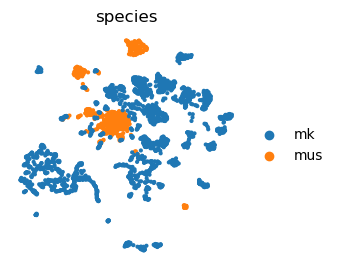

In [32]:
sc.pl.umap(adata,color='species',frameon=False,legend_loc='right margin')

In [79]:
# figsize(3,3)
# sc.pl.umap(adata,color=['MOG'],frameon=False,legend_loc='right margin')

# remove the batch effects and integrate the data

### Integrate data with SCVI

In [ ]:
# adata = scvi.data.read_h5ad("dataH5/saveBeforeSCVI_3.h5ad")

In [33]:
adata0 = sc.read('./temData/mergedGlia_tasic_ins_v3.h5ad')
adata.X = adata0[:,adata.var_names].X[:]
adata.X.todense()

matrix([[  0.,   0.,   0., ...,   0.,   0., 283.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   1.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]], dtype=float32)

In [34]:
scvi.model.SCVI.setup_anndata(
    adata,
    batch_key = 'batch',
    categorical_covariate_keys=['species'],
    continuous_covariate_keys = ['n_genes','total_counts']
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [35]:
model = scvi.model.SCVI(adata)

In [36]:
model.train(600)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 600/600: 100%|██████████████| 600/600 [03:13<00:00,  3.17it/s, v_num=1, train_loss_step=185, train_loss_epoch=164]

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████████| 600/600 [03:13<00:00,  3.10it/s, v_num=1, train_loss_step=185, train_loss_epoch=164]


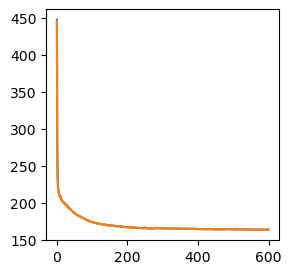

In [37]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['train_loss_epoch'])

In [38]:
adata.obsm['X_scvi'] = model.get_latent_representation()

In [39]:
sc.pp.neighbors(adata, use_rep="X_scvi")
sc.tl.umap(adata, min_dist=0.3)

In [40]:
adata

AnnData object with n_obs × n_vars = 3371 × 500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'species_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scvi'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

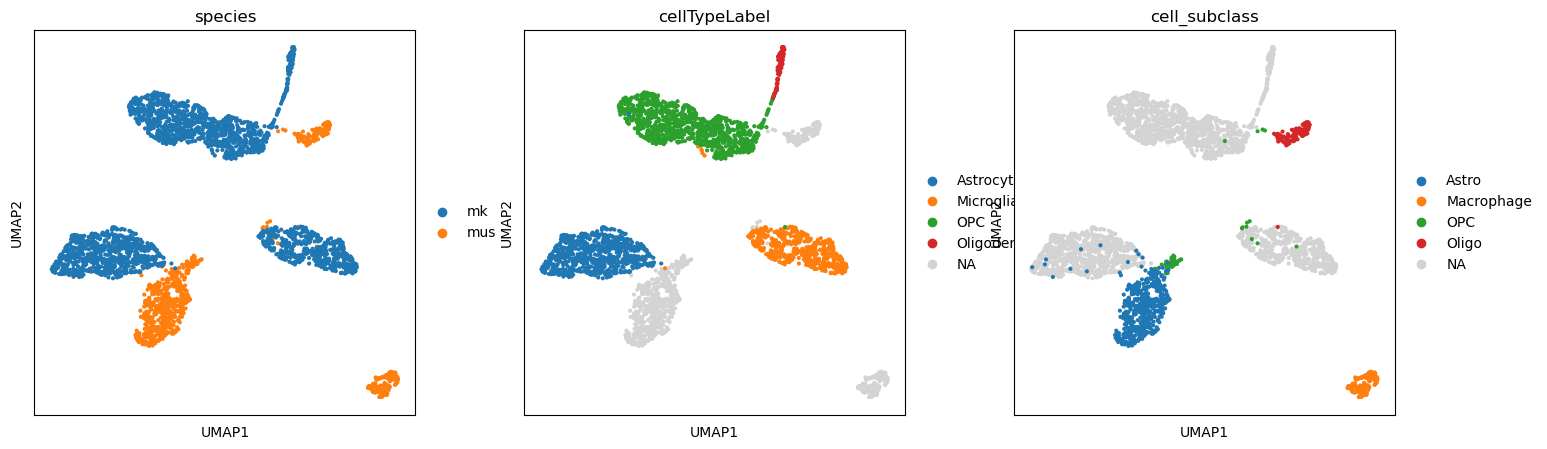

In [41]:
figsize(5,5)
sc.pl.umap(adata, color=['species','cellTypeLabel','cell_subclass'])

### Integrate data with harmony

In [42]:
import harmonypy as hm
# ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, ['species','sequencing_batch_mus','sequenceing_batch_mk'],theta=10,max_iter_harmony=10,max_iter_kmeans=20)
ho = hm.run_harmony(adata.obsm['X_scvi'], adata.obs, ['species'])

adata.obsm['X_harmonypca'] = ho.Z_corr.T
sc.pp.neighbors(adata, use_rep='X_harmonypca')

adata.obsm['X_umapraw'] = adata.obsm['X_umap']
sc.tl.umap(adata)
adata.obsm['X_umapharmony'] = adata.obsm['X_umap']

2025-09-14 21:38:56,935 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-14 21:38:57,912 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-14 21:38:57,926 - harmonypy - INFO - Iteration 1 of 10
2025-09-14 21:38:58,498 - harmonypy - INFO - Iteration 2 of 10
2025-09-14 21:38:59,125 - harmonypy - INFO - Iteration 3 of 10
2025-09-14 21:38:59,710 - harmonypy - INFO - Iteration 4 of 10
2025-09-14 21:39:00,339 - harmonypy - INFO - Converged after 4 iterations


In [43]:
adata

AnnData object with n_obs × n_vars = 3371 × 500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'species_colors', '_scvi_uuid', '_scvi_manager_uuid', 'cellTypeLabel_colors', 'cell_subclass_colors'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scvi', 'X_harmonypca', 'X_umapraw', 'X_umapharmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

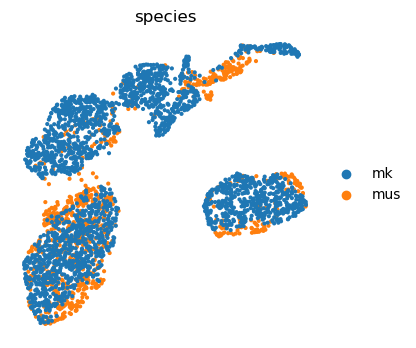

In [44]:
figsize(4,4)
sc.pl.umap(adata,color='species',frameon=False,legend_loc='right margin')

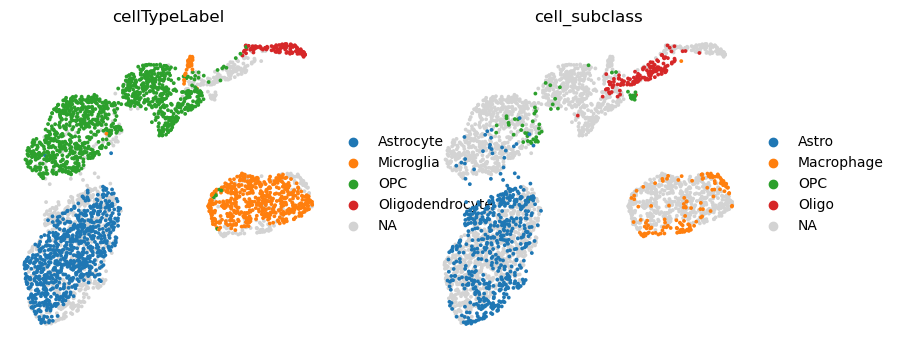

In [45]:
sc.pl.umap(adata,color=['cellTypeLabel','cell_subclass'],s=30,frameon=False,legend_loc='right margin')

In [46]:
%pylab inline
import sys
sys.path.append('../tools')
from two_species_heatmap import *

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [47]:
ad_merged_mk_hu_integrated = adata.copy()
ad_merged_mk_hu_integrated

AnnData object with n_obs × n_vars = 3371 × 500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'species_colors', '_scvi_uuid', '_scvi_manager_uuid', 'cellTypeLabel_colors', 'cell_subclass_colors'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scvi', 'X_harmonypca', 'X_umapraw', 'X_umapharmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

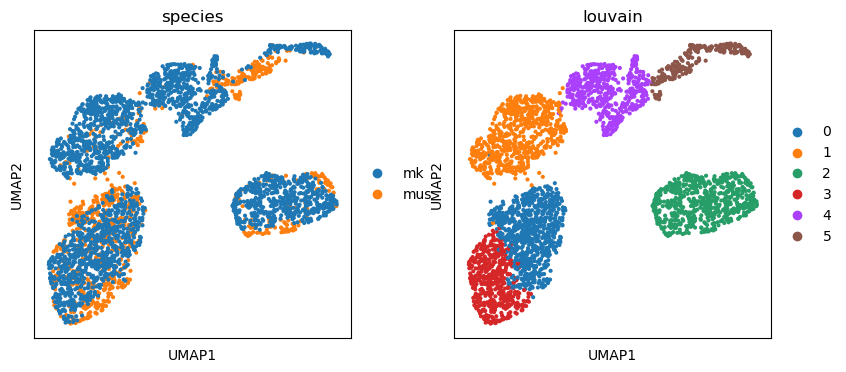

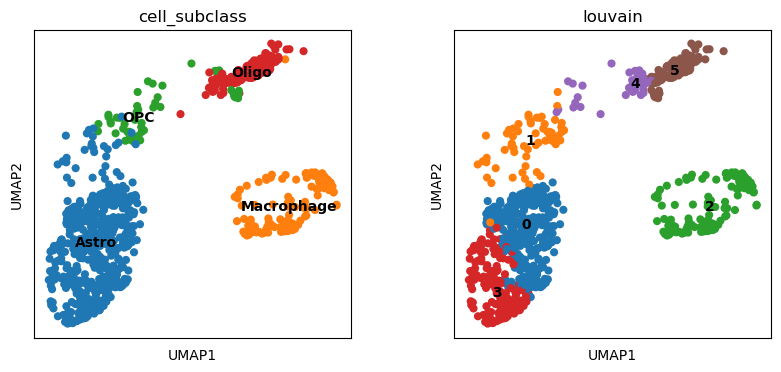

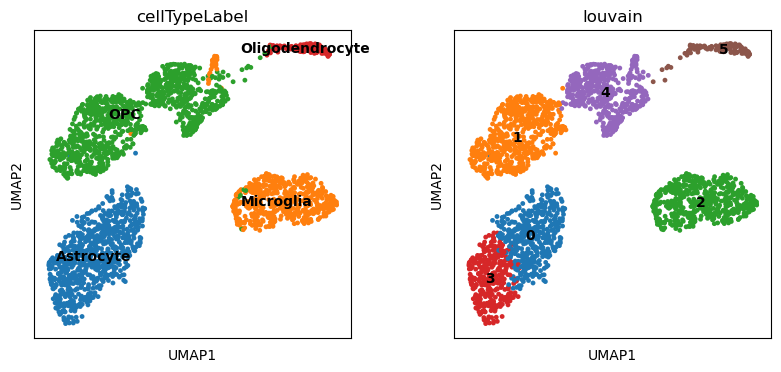

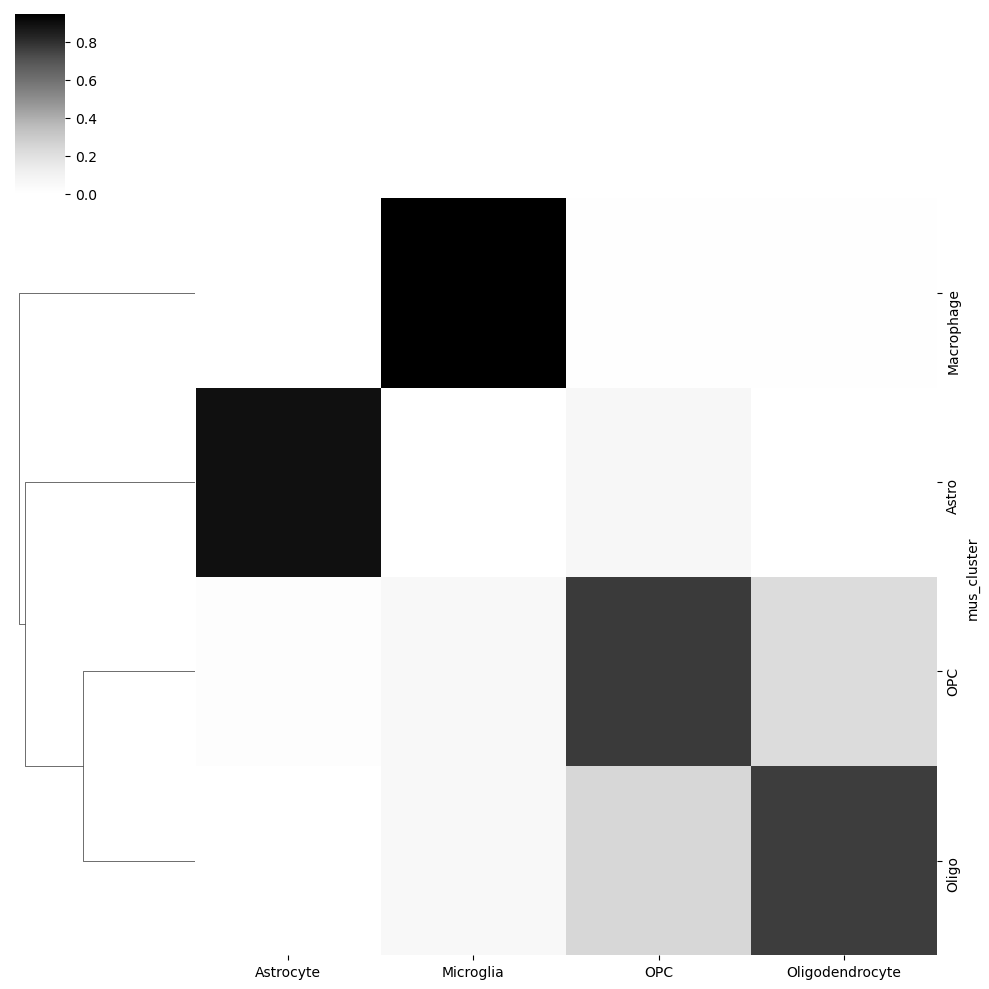

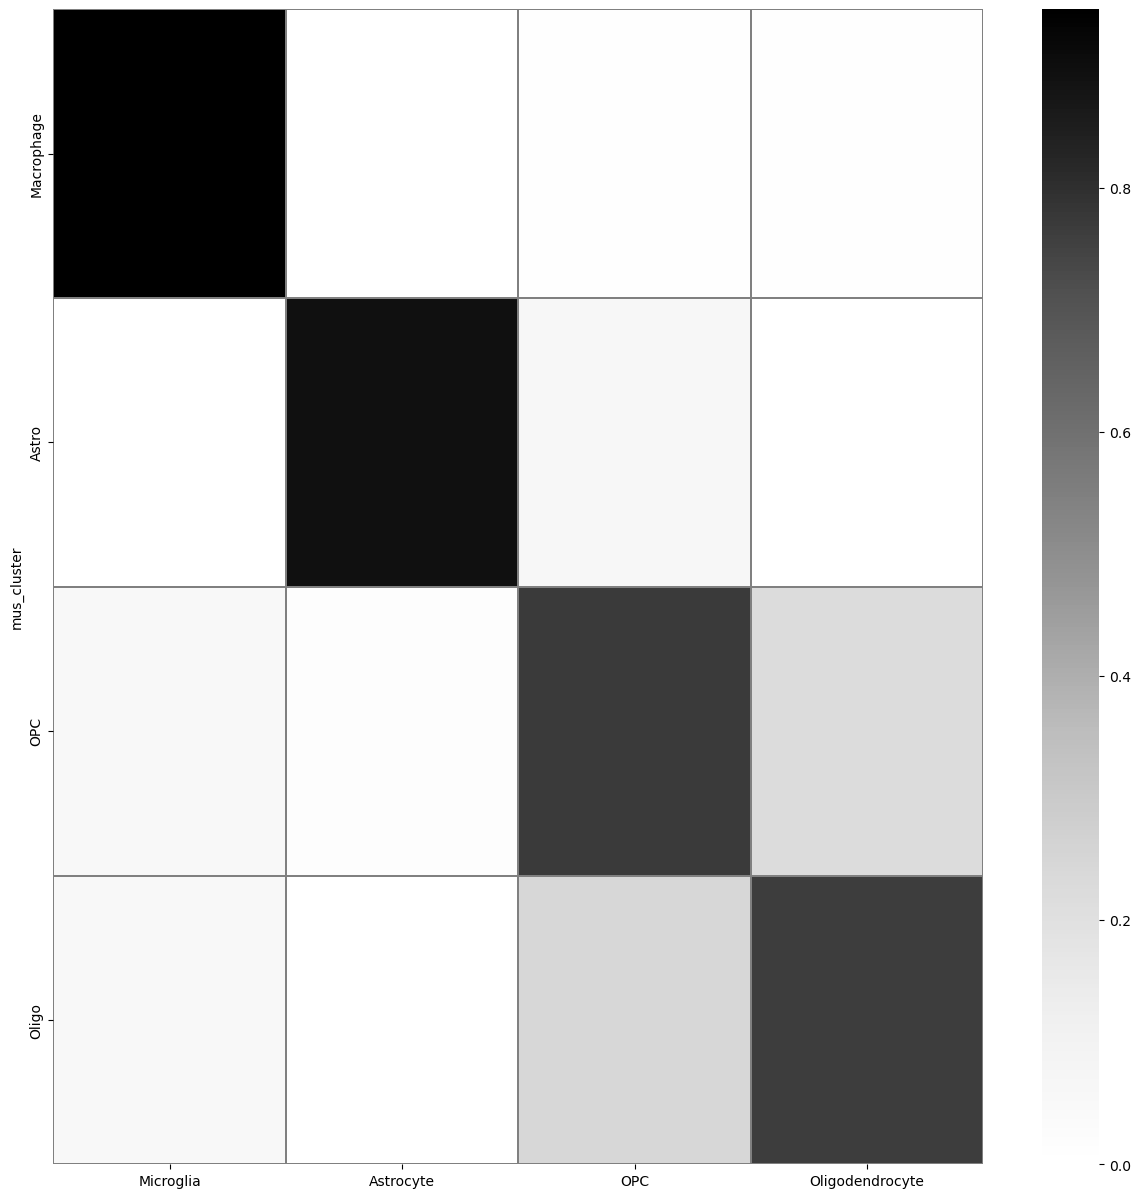

In [53]:
plot_cmpMatrix_mk_vs_mus_lovain_0_3 = two_species_heatmap(ad_merged_mk_hu_integrated, species_1 = 'mus', species_2 = 'mk',\
                species_1_key = 'cell_subclass', species_2_key = 'cellTypeLabel',\
                louvain = 0.3)#,figure_path = 'neurons_heatmap_cmp.png')

In [51]:
# index_order = ['Macrophage','Oligo','Astro','OPC']
# column_order = ['Microglia','Oligodendrocyte','Astrocyte','OPC']
# plot_cmpMatrix_mk_vs_mus_lovain_0_1=plot_cmpMatrix_mk_vs_mus_lovain_0_1.reindex(index=index_order,columns=column_order)

### plot the figures and save data...

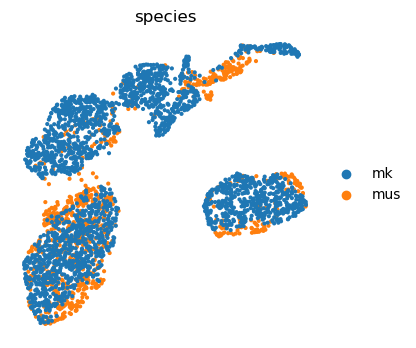

In [55]:
figsize(4,4)
sc.pl.umap(adata,color='species',frameon=False,legend_loc='right margin',save='_mergedAllGlia_mk_vs_mus_speciesCmp.pdf')

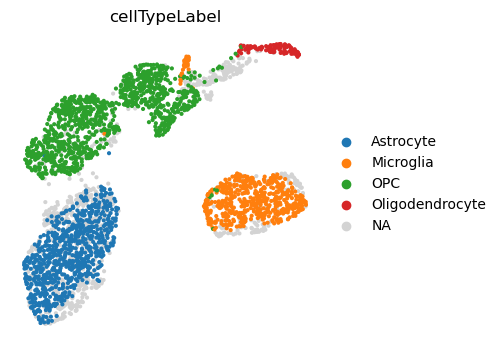

In [56]:
sc.pl.umap(adata,color='cellTypeLabel',frameon=False,legend_loc='right margin',save='_mergedAllGlia_mk_vs_mus_Ins.pdf')

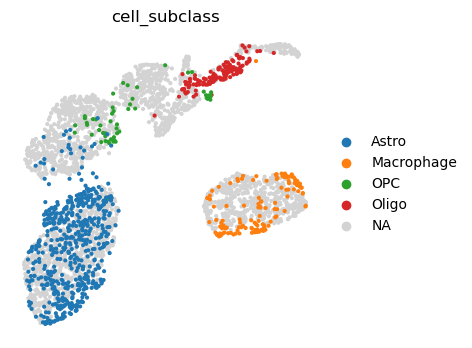

In [57]:
sc.pl.umap(adata,color='cell_subclass',frameon=False,legend_loc='right margin',save='_mergedAllGlia_mk_vs_mus_Tasic.pdf')

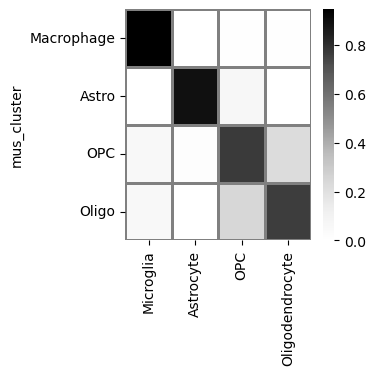

In [58]:
plt.figure(figsize = (3,3))
sns_plot = sns.heatmap(plot_cmpMatrix_mk_vs_mus_lovain_0_3, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 1, linecolor = 'gray')
savefig('./figs/GliaCmp_Tasic_vs_Ins.pdf',dpi=300,format='pdf')

In [61]:
ad_merged_mk_hu_integrated.write('./data_tem/ad_merged_mk_mus_integrated_allGlia_final.h5ad')
plot_cmpMatrix_mk_vs_mus_lovain_0_3.to_csv('./plot_cmpMatrix_mk_vs_mus_lovain_0_3_integrateTasic_glia.csv')